In [24]:
import nltk
import re
import string
from nltk.corpus import stopwords
from trnlp import TrnlpWord
from gensim.models import Word2Vec

# Türkçe stopword'leri indir ve yükle
nltk.download("stopwords")
stop_words = set(stopwords.words("turkish"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ertuğrul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
# Metin ön işleme ve kökleme fonksiyonu
def preprocess_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", " ", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = []
    for word in text.split():
        if word not in stop_words:
            analyzer = TrnlpWord()
            analyzer.setword(word)
            root = analyzer.get_stem
            if root and root.strip():
                words.append(root)
            else:
                words.append(word)
    return words

In [26]:
# Genişletilmiş corpus
corpus = [
    "Yapay zeka, teknoloji dünyasında devrim yaratıyor.",
    "Yapay zeka sektöründe yeni gelişmeler yaşanıyor.",
    "Yapay zeka ve otomasyon, iş gücü piyasasında önemli değişikliklere yol açacak.",
    "Yapay zeka, makinelerin insan benzeri düşünme ve öğrenme yeteneklerini kazanmasını sağlıyor.",
    "Yapay zeka ve makine öğrenimi, sağlık sektöründe önemli rol oynamaktadır.",
    "Yapay zeka teknolojileri, işletmelerin verimliliklerini artırmalarına yardımcı oluyor.",
    "Yapay zeka, insan zekâsına benzer şekilde veri analizi yapabilir.",
    "Yapay zeka, bilgisayarların daha hızlı ve doğru kararlar almasını sağlar.",
    "Yapay zeka, doğal dil işleme ve konuşma tanıma alanlarında büyük ilerlemeler kaydetmiştir.",
    "Yapay zeka, sağlık sektöründe erken teşhis ve tedavi süreçlerinde devrim yaratacak.",
    "Ekonomi, son çeyrekte büyüme kaydetti.",
    "Türkiye ekonomisi son yıllarda önemli bir büyüme gösterdi.",
    "Ekonomi, dünya genelindeki ticaret hacmi ile şekillendi.",
    "Merkez bankası faiz oranlarını artırarak enflasyonu kontrol altına almayı hedefliyor.",
    "Döviz kuru artışı, ekonomi üzerinde baskı oluşturuyor.",
    "Spor dünyası, yeni transferlerle daha da heyecan verici hale geldi.",
    "Futbol, Türkiye'nin en popüler spor dalı olmaya devam ediyor.",
    "Basketbol, son yıllarda gençler arasında daha fazla ilgi görmeye başladı.",
    "Teknoloji, günlük hayatı dönüştürmek için her geçen gün yeni adımlar atıyor.",
    "Yapay zeka, otomotiv sektöründe önemli yeniliklere yol açtı.",
    "Bilgisayarlar, oyun dünyasında devrim niteliğinde yenilikler sunuyor.",
    "Yapay zeka, eğitim sektöründe kişiye özel eğitim deneyimleri sunuyor.",
    "Ekonomik büyüme, ülkelerin gelişmişlik düzeyine göre farklılık gösteriyor.",
    "Sosyal medya, insanların birbirleriyle olan etkileşimlerini değiştiriyor.",
    "Spor, insanların sağlıklı kalmalarına yardımcı olabilecek önemli bir aktivite.",
    "Teknoloji, endüstri 4.0'ı mümkün kılıyor.",
    "Yapay zeka, insan hayatını daha güvenli ve verimli hale getirebilir.",
    "Sağlık sektöründe yapay zekâ ile tedavi süreçleri hızlanabilir.",
    "Ekonomi, sadece ticaret değil, aynı zamanda sosyal ilişkileri de etkiler.",
    "Yapay zeka, hızla gelişen ve evrimleşen bir teknolojidir.",
    "Teknoloji, iş dünyasında yeni fırsatlar yaratmaya devam ediyor.",
    "Spor, insanlar için sadece bir eğlence değil, aynı zamanda bir yaşam biçimi.",
    "Ekonomik kriz, dünya genelinde birçok ülkeyi etkiledi.",
    "Teknolojik gelişmeler, insan hayatını her alanda kolaylaştırıyor.",
    "Yapay zeka, robot teknolojileri ile birleşerek daha güçlü bir sistem oluşturuyor.",
    "Yapay zeka, doğal afetleri önceden tahmin etmek için kullanılabilir.",
    "Yapay zeka, iş gücü piyasasında büyük bir dönüşüm yaratıyor.",
    "Spor, hem fiziksel hem de zihinsel sağlığı destekleyen önemli bir etkinliktir.",
    "Yapay zeka, özellikle sağlık sektöründe çok büyük bir potansiyele sahiptir.",
    "Yapay zeka, enerji sektöründe de verimliliği artıran çözümler sunmaktadır.",
    "Ekonomi, dünya genelindeki tedarik zincirlerine dayanır.",
    "Yapay zeka, iş yerlerinde daha verimli bir çalışma ortamı sağlayabilir.",
    "Futbol, dünyada en çok izlenen spor dalıdır.",
    "Teknoloji, insanların yaşam kalitesini artırmaya yardımcı olmaktadır.",
    "Yapay zeka, farklı endüstrilerde daha fazla kullanılmaya başlandı.",
    "Ekonomi, küresel ticaretle doğrudan ilişkilidir.",
    "Yapay zeka, eğitimde kişiye özel öğrenme yolları sunabilir.",
    "Teknolojik yenilikler, dünya ekonomisini hızla şekillendiriyor.",
    "Yapay zeka, makine öğrenimi ve derin öğrenme gibi kavramlarla büyümeye devam ediyor.",
    "Sağlık sektöründe teknoloji, yaşam süresini uzatmaya yardımcı olabilir.",
    "Yapay zeka, endüstriyel süreçlerde daha verimli sonuçlar elde edilmesini sağlar.",
    "Yapay zeka, insan hayatında her geçen gün daha fazla rol oynamaya başladı.",
    "Yapay zeka, bilimsel araştırmaların hızlanmasına yardımcı olabilir.",
    "Teknoloji, her alanda devrim yaratmaya devam ediyor.",
    "Yapay zeka, medikal teşhislerde büyük bir devrim yaratıyor."
]


# Metinleri işleyelim
processed_corpus = [preprocess_text(text) for text in corpus]

In [28]:
# Word2Vec modelini eğit
model = Word2Vec(sentences=processed_corpus, vector_size=100, window=5, min_count=1, workers=4, sg=1)  # sg=1 -> Skip-Gram modeli

# Örnek: "yapay" kelimesine en benzer 5 kelimeyi yazdır
print("\nEn benzer kelimeler: 'zekâ'")
print(model.wv.most_similar("zekâ", topn=5))


En benzer kelimeler: 'zekâ'
[('dünyada', 0.30135104060173035), ('kalma', 0.2854250371456146), ('popüler', 0.27996522188186646), ('etkinlik', 0.24654357135295868), ('büyü', 0.23825450241565704)]


In [29]:
# 'sağlık' kelimesine en benzer kelimeler
print("En benzer kelimeler: 'sağlık'")
print(model.wv.most_similar("sağlık", topn=5))

En benzer kelimeler: 'sağlık'
[('sağlıklı', 0.31432604789733887), ('etkinlik', 0.263454407453537), ('rol', 0.2511788308620453), ('kolaylaştır', 0.23489990830421448), ('zekâ', 0.23198585212230682)]


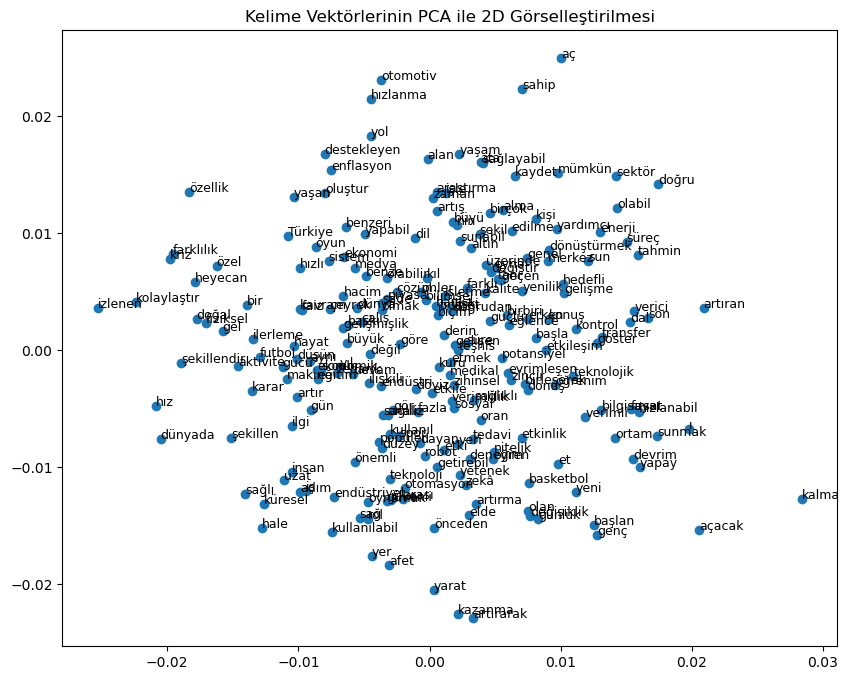

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Kelimelerin vektör temsilini al
word_vectors = model.wv[model.wv.key_to_index]

# PCA ile boyut indirgeme
pca = PCA(n_components=2)
pca_result = pca.fit_transform(word_vectors)

# En yüksek frekanslı kelimeleri seç
words = list(model.wv.key_to_index.keys())

# Görselleştirme
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1])

# Kelimeleri etiketle
for i, word in enumerate(words):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]), fontsize=9)

plt.title('Kelime Vektörlerinin PCA ile 2D Görselleştirilmesi')
plt.show()